# CPE15 Activity 08
## Matplotlib Bar Graphs and Scatter Plots

**Scenario:** Evacuation-Center Readiness Comparison  
**Course:** Professional Elective 1: Programming for Data Science  
**Week:** 9  
**Mode:** Individual, in class or take home  
**Suggested completion time:** 5 to 6 hours  
**Total:** 100 points

### Student Information

**Name:** ROLLIE ANGELO R. GARCIA    
**Student number:** 24-000455    
**Section:** BS-CPE GF-III  
**Date performed:** 2026-09-25  
**Date submitted:** 2026-09-25

> Rename this file as `Surname_Firstname_CPE15_Activity08.ipynb` before submission.

## Activity Purpose

Compare synthetic evacuation-center capacity, occupancy, supplies, accessibility, and travel time using vertical, horizontal, grouped, stacked, and annotated bar graphs plus a multivariable scatter plot.

## Learning Outcomes

1. Construct vertical and horizontal bar graphs with correct dimensions.
2. Create grouped and stacked bar graphs from comparable quantities.
3. Place annotations with intentional horizontal and vertical alignment.
4. Encode scatter position, size, color, and category without ambiguity.
5. Validate, interpret, and export an accessible readiness figure.

## General Instructions

1. Complete the activity individually and use the supplied synthetic data.
2. Do not delete or rewrite a cell labeled **STARTER DATA**.
3. Write the requested prediction before executing each part.
4. Complete every **STUDENT CODE** cell and keep the output visible.
5. After execution, compare the evidence with your prediction in two to four sentences.
6. Label quantities with units, denominators, and scope.
7. Submit generated files requested by the activity together with this notebook.
8. Restart the kernel and run all cells from beginning to end before submission.

No separate laboratory report is required.

## Required CSV Files

Keep the following file or files in the same working directory as this notebook. Do not rename them.

1. `CPE15_Activity08_Evacuation_Centers.csv`

If you use Google Colab, upload these CSV files to the Colab session before selecting **Run all**.


## Part 1: Validate Center-Level Data (10 points)

**Context:** Each row is one synthetic evacuation center with capacity, assigned households, travel time, accessibility score, and supply counts.

### Required Tasks

1. Build the DataFrame.
2. Verify unique center IDs and nonnegative numeric values.
3. Calculate occupancy percentage.
4. Flag assignments above capacity.
5. Report all units.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 1 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**  
I predict the audit will report 12 evacuation centers with unique `center_id` values, no missing values, and all numeric columns nonnegative. Because one center is deliberately assigned more people than its capacity, I expect exactly one over-capacity flag, giving an occupancy percentage range from roughly 69% to about 160% with a mean near 88%.

In [1]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = Path('CPE15_Activity08_Evacuation_Centers.csv')
centers = pd.read_csv(DATA_FILE)
print(f'Loaded {len(centers)} evacuation centers from {DATA_FILE.name}')

Loaded 12 evacuation centers from CPE15_Activity08_Evacuation_Centers.csv


In [2]:
# STUDENT CODE: Audit the records and derive occupancy percentage.

# Unique center IDs
print('Unique center IDs:', centers['center_id'].is_unique)
print('Duplicate IDs:', int(centers['center_id'].duplicated().sum()))

# Missing values and nonnegative numeric columns
numeric_cols = ['capacity', 'assigned_households', 'assigned_people',
                'travel_time_min', 'access_score', 'water_kits',
                'food_kits', 'medical_kits']
print('Missing values:', int(centers.isna().sum().sum()))
print('All numeric values nonnegative:', bool((centers[numeric_cols] >= 0).all().all()))
print('Positive capacities:', bool((centers['capacity'] > 0).all()))

# Occupancy percentage = assigned_people / capacity * 100
centers['occupancy_pct'] = centers['assigned_people'] / centers['capacity'] * 100

# Flag assignments above capacity
over = centers[centers['assigned_people'] > centers['capacity']]
print('Over-capacity centers:')
print(over[['center_id', 'center_name', 'capacity', 'assigned_people',
            'occupancy_pct']].round(1).to_string(index=False))

# Units and scope
print('Observation unit: one evacuation center')
print('Units: capacity/people in persons; travel_time_min in minutes;',
      'access_score 0-100; kits in kits per center; occupancy in % of capacity')
print('Occupancy range:',
      f"{centers['occupancy_pct'].min():.1f}% to {centers['occupancy_pct'].max():.1f}%",
      f"(mean {centers['occupancy_pct'].mean():.1f}%)")

# Add validation and labeled output required by the instructions.

Unique center IDs: True
Duplicate IDs: 0
Missing values: 0
All numeric values nonnegative: True
Positive capacities: True
Over-capacity centers:
center_id    center_name  capacity  assigned_people  occupancy_pct
      C01 City Gymnasium       150              240          160.0
Observation unit: one evacuation center
Units: capacity/people in persons; travel_time_min in minutes; access_score 0-100; kits in kits per center; occupancy in % of capacity
Occupancy range: 68.9% to 160.0% (mean 88.2%)


### Part 1 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
The audit confirmed 12 centers with unique IDs, no missing values, and all numeric columns nonnegative. Occupancy percentage, defined as assigned people divided by capacity times 100, ranges from 68.9% (Mountain View Station) to 160.0% (City Gymnasium), the only over-capacity center, with a mean of 88.2%. The unit is percent of capacity, and the observational unit is one center. A limitation is that occupancy relies on reported headcounts, which are synthetic and not field-verified.

## Part 2: Vertical and Horizontal Bar Graphs (10 points)

**Context:** Capacity and occupancy percentage answer different comparison questions.

### Required Tasks

1. Create a vertical capacity bar graph with width and edge styling.
2. Create a horizontal occupancy graph with bar height.
3. Sort the horizontal graph by occupancy.
4. Use xerr or yerr only if an uncertainty quantity is explicitly supplied; otherwise omit it.
5. Explain width for bar and height for barh.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 2 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the vertical capacity bar graph will rank centers by size, making University Pavilion the tallest bar (300 persons) and Mountain View Station the shortest (90). I predict the horizontal occupancy graph, sorted ascending by occupancy, will progress from 68.9% at the top to 160.0% (City Gymnasium) at the bottom, so the over-capacity center becomes the longest bar.

In [3]:
# STARTER DATA: Do not manually alter these values.
# STARTER DATA: Continue using centers.

Text(0.5, 1.0, 'Evacuation-center occupancy (sorted)')

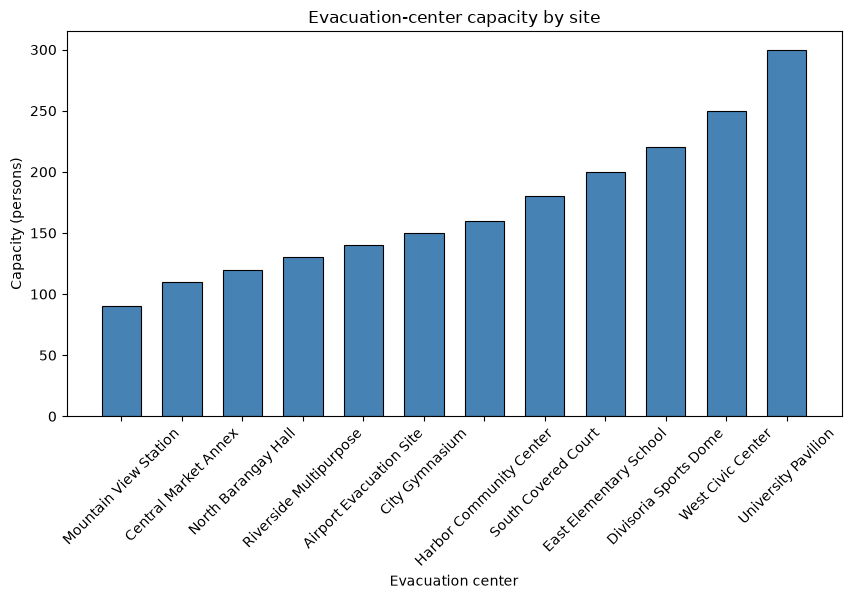

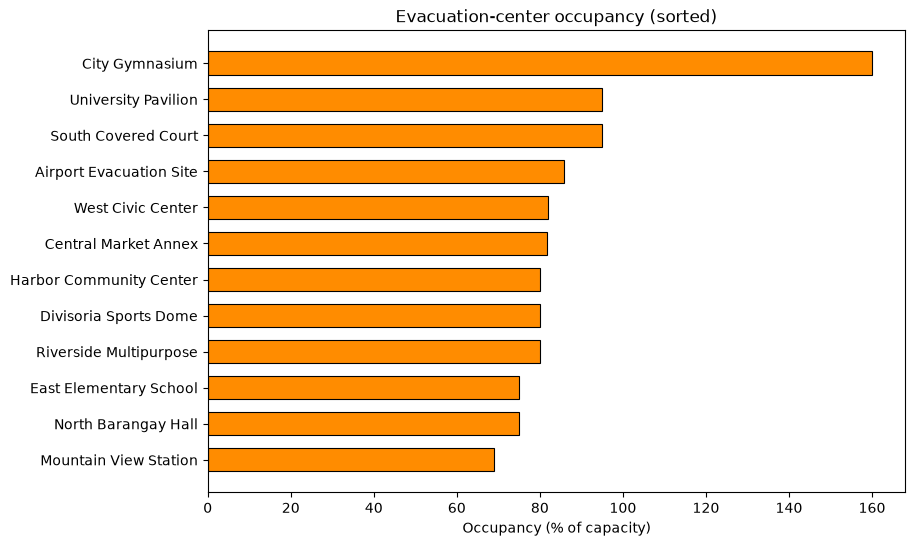

In [4]:
# STUDENT CODE: Create one vertical and one horizontal comparison.

# --- Vertical capacity bars ---
fig, ax = plt.subplots(figsize=(10, 5))
order = centers.sort_values('capacity')
ax.bar(order['center_name'], order['capacity'],
       width=0.65, color='steelblue', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Evacuation center')
ax.set_ylabel('Capacity (persons)')
ax.set_title('Evacuation-center capacity by site')
ax.tick_params(axis='x', rotation=45)

# --- Horizontal occupancy bars (sorted by occupancy) ---
fig, ax = plt.subplots(figsize=(9, 6))
ordered = centers.sort_values('occupancy_pct')
ax.barh(ordered['center_name'], ordered['occupancy_pct'],
        height=0.65, color='darkorange', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Occupancy (% of capacity)')
ax.set_title('Evacuation-center occupancy (sorted)')

# Add validation and labeled output required by the instructions.

### Part 2 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**

The vertical chart compares absolute capacity, measured in persons per center, so it ranks by size; the horizontal chart compares occupancy percentage and is sorted so the least utilized center is at the top and City Gymnasium's 160% bar is the longest. For `bar()`, `width` sets bar thickness along the category axis; for `barh()`, it is the `height` of each horizontal bar. A limitation is that no standard-error column was supplied, so error bars were correctly omitted rather than invented.

## Part 3: Grouped and Stacked Bars (10 points)

**Context:** Capacity versus assignments should be grouped; supply categories may be stacked when the total kit count is meaningful.

### Required Tasks

1. Create grouped bars for capacity and assigned people.
2. Create stacked bars for water, food, and medical kits using bottom.
3. Add legends and units.
4. Calculate each stack total and explain what the total does and does not mean.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 3 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the grouped bars will let capacity and assigned people be compared side by side for every center, showing City Gymnasium's assignments clearly exceeding its capacity. I predict the stacked bars will sum water, food, and medical kits, with University Pavilion having the largest stack total (890 kits) and Mountain View Station the smallest (160).

In [5]:
# STARTER DATA: Do not manually alter these values.
x = np.arange(len(centers)); group_width = 0.36

Largest stack total: {'center_name': 'University Pavilion', 'total_kits': 890}
Smallest stack total: {'center_name': 'Mountain View Station', 'total_kits': 160}


/tmp/ipykernel_401656/1828266664.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(centers['center_name'], rotation=45, ha='right')


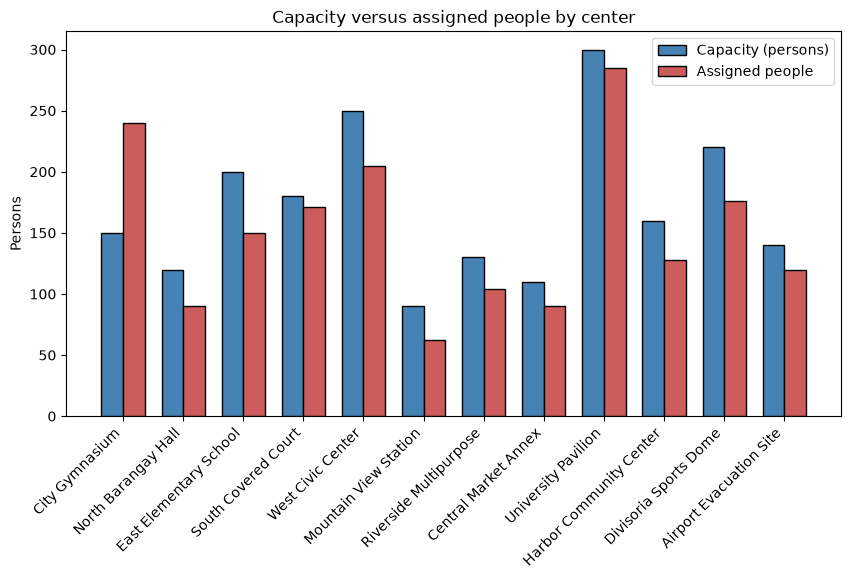

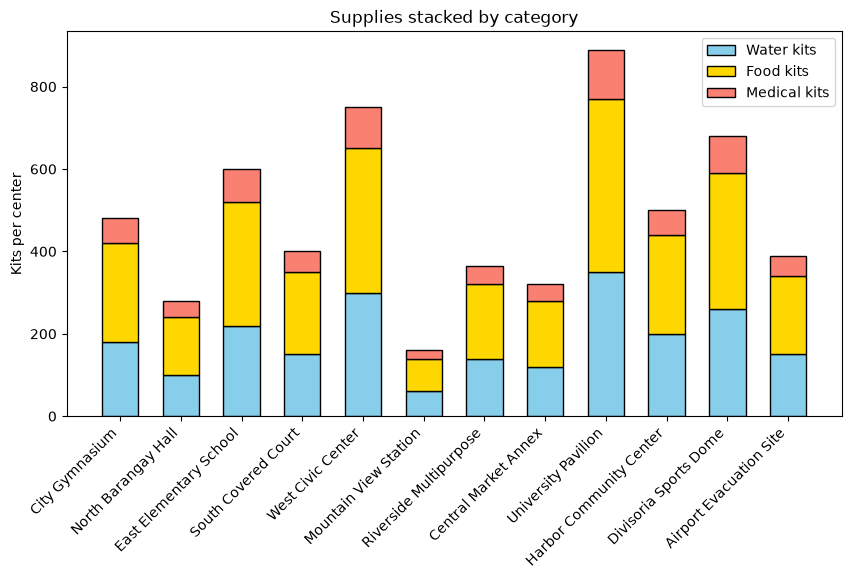

In [6]:
# STUDENT CODE: Build grouped and stacked bar figures.

# --- Grouped bars: capacity vs assigned people ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(centers))
group_width = 0.36

ax.bar(x - group_width / 2, centers['capacity'], group_width,
       label='Capacity (persons)', color='steelblue', edgecolor='black')
ax.bar(x + group_width / 2, centers['assigned_people'], group_width,
       label='Assigned people', color='indianred', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(centers['center_name'], rotation=45, ha='right')
ax.set_ylabel('Persons')
ax.set_title('Capacity versus assigned people by center')
ax.legend(loc='upper right')

# --- Stacked bars: water, food, and medical kits ---
fig, ax = plt.subplots(figsize=(10, 5))
p1 = ax.bar(centers['center_name'], centers['water_kits'], 0.6,
            label='Water kits', color='skyblue', edgecolor='black')
p2 = ax.bar(centers['center_name'], centers['food_kits'], 0.6,
            bottom=centers['water_kits'], label='Food kits',
            color='gold', edgecolor='black')
p3 = ax.bar(centers['center_name'], centers['medical_kits'], 0.6,
            bottom=centers['water_kits'] + centers['food_kits'],
            label='Medical kits', color='salmon', edgecolor='black')

centers['total_kits'] = (centers['water_kits'] + centers['food_kits']
                         + centers['medical_kits'])
print('Largest stack total:', centers.loc[centers['total_kits'].idxmax(),
                                          ['center_name', 'total_kits']].to_dict())
print('Smallest stack total:', centers.loc[centers['total_kits'].idxmin(),
                                           ['center_name', 'total_kits']].to_dict())

ax.set_xticklabels(centers['center_name'], rotation=45, ha='right')
ax.set_ylabel('Kits per center')
ax.set_title('Supplies stacked by category')
ax.legend(loc='upper right')

# Add validation and labeled output required by the instructions.

### Part 3 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
Grouped bars keep capacity and assigned people as adjacent, comparable columns so the over-capacity case, City Gymnasium, is readable directly from assignments exceeding capacity. Stacked bars sum the three kit categories into a total that is meaningful only because all three are measured in the same unit, kits per center. The total does not equal the number of people or households that can be supported, so it must not be read as sufficiency. Units are persons for the grouped chart and kits per center for the stacked chart.

## Part 4: Annotations and Alignment (10 points)

**Context:** The occupancy bars need exact labels without obscuring the comparison.

### Required Tasks

1. Use ax.bar_label or annotate.
2. Demonstrate ha and va choices.
3. Use a capstyle on a reference or annotation line if appropriate.
4. Keep labels inside the axes and legible.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 4 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the occupancy bars will carry exact value labels placed with intentional horizontal and vertical alignment so the numbers stay legible and inside the axes, and a vertical reference line at 100% capacity will mark the safe boundary with a styled capstyle. City Gymnasium's 160% label will be the most extreme because it is the only bar beyond capacity.

In [7]:
# STARTER DATA: Do not manually alter these values.
ordered = centers.sort_values('occupancy_pct')

Text(0.5, 1.0, 'Evacuation-center occupancy with labels and capacity reference')

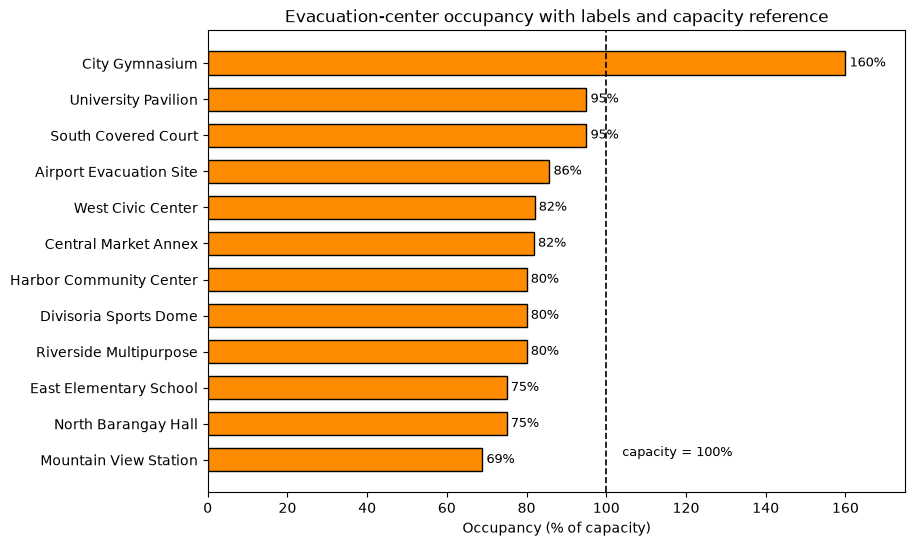

In [8]:
# STUDENT CODE: Add readable value labels and a styled reference line.

ordered = centers.sort_values('occupancy_pct')

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(ordered['center_name'], ordered['occupancy_pct'],
               height=0.65, color='darkorange', edgecolor='black')

# Labels with explicit alignment: 'center' horizontally, 'bottom' vertically.
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in ordered['occupancy_pct']],
             label_type='edge', padding=3,
             fontsize=9)

# Reference line at the 100% capacity boundary with round capstyle.
ref = ax.axvline(100, color='black', linestyle='--', linewidth=1.2,
                 solid_capstyle='round')

ax.annotate('capacity = 100%', xy=(100, 0), xytext=(104, 0.2),
            horizontalalignment='left', verticalalignment='center',
            fontsize=9)

ax.set_xlim(0, 175)
ax.set_xlabel('Occupancy (% of capacity)')
ax.set_title('Evacuation-center occupancy with labels and capacity reference')

# Add validation and labeled output required by the instructions.

### Part 4 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
Value labels were placed with `bar_label` and explicit alignment so each percentage sits cleanly outside its bar tip without covering the comparison, and the extreme 160% label for City Gymnasium remains inside the axes. The reference line at 100% capacity with a rounded capstyle marks the safe boundary, while the capstyle controls how the line ends, not the data. The unit is percent of capacity per center. A limitation is that very short bars (68.9%) need the padding tuned so their labels do not collide.

## Part 5: Multivariable Scatter Plot and Final Export (15 points)

**Context:** Readiness depends on travel time, accessibility, assignment load, and capacity.

### Required Tasks

1. Map travel time to x and access score to y.
2. Map capacity to marker size and occupancy percentage to color.
3. Add a colorbar, center labels, readable size scaling, and reference lines.
4. Export and verify the PNG.
5. State what every visual channel means.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 5 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the scatter plot will show travel time from 5 to 28 minutes on the x-axis and access scores between 70 and 95 on the y-axis, with marker size scaling by capacity and color scaling by occupancy percentage. I expect City Gymnasium to have the darkest marker (160% occupancy), University Pavilion the largest marker (300 persons), Airport Evacuation Site to sit low-right (28 min, 70 access), and only a weak negative trend between longer travel and lower access.

In [9]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
scatter_path = Path('activity08_readiness_scatter.png')

Saved: activity08_readiness_scatter.png
File exists: True
File size (bytes): 195828
Visual channels: x = travel_time_min (minutes); y = access_score (0-100);
marker area = capacity (persons); marker color = occupancy_pct (% of capacity)


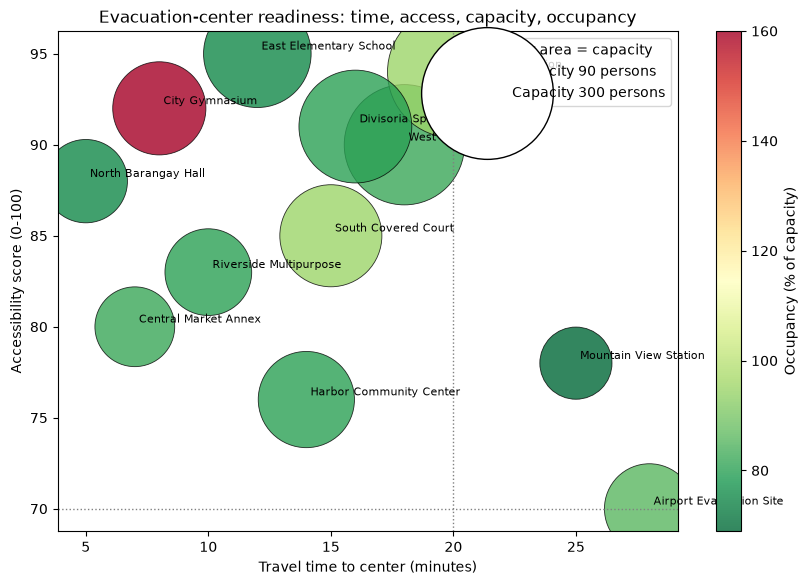

In [10]:
# STUDENT CODE: Create, label, export, and verify the scatter plot.

from pathlib import Path
scatter_path = Path('activity08_readiness_scatter.png')
markersize_scale = 30  # area scaling constant

fig, ax = plt.subplots(figsize=(10, 6.5))

sc = ax.scatter(centers['travel_time_min'], centers['access_score'],
                s=centers['capacity'] * markersize_scale,
                c=centers['occupancy_pct'], cmap='RdYlGn_r',
                alpha=0.8, edgecolor='black', linewidth=0.6)

# Center labels offset from the points.
for _, row in centers.iterrows():
    ax.annotate(row['center_name'], (row['travel_time_min'], row['access_score']),
                xytext=(3, 3), textcoords='offset points', fontsize=8)

# Reference lines.
ax.axhline(70, color='gray', linestyle=':', linewidth=1)
ax.axvline(20, color='gray', linestyle=':', linewidth=1)

# Colorbar for occupancy.
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Occupancy (% of capacity)')

# Size legend (2 example sizes).
for cap in (90, 300):
    ax.scatter([], [], s=cap * markersize_scale, color='white',
               edgecolor='black', label=f'Capacity {cap} persons')
ax.legend(loc='upper right', title='Marker area = capacity')

ax.set_xlabel('Travel time to center (minutes)')
ax.set_ylabel('Accessibility score (0-100)')
ax.set_title('Evacuation-center readiness: time, access, capacity, occupancy')

# Export and verify.
fig.savefig(scatter_path, dpi=180, bbox_inches='tight', facecolor='white')
print('Saved:', scatter_path)
print('File exists:', scatter_path.exists())
print('File size (bytes):', scatter_path.stat().st_size)
assert scatter_path.exists() and scatter_path.stat().st_size > 0

print('Visual channels: x = travel_time_min (minutes); y = access_score (0-100);')
print('marker area = capacity (persons); marker color = occupancy_pct (% of capacity)')

# Add validation and labeled output required by the instructions.

### Part 5 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
The scatter encodes four variables without ambiguity: x is travel time in minutes, y is the 0-100 access score, marker area is capacity in persons, and marker color is occupancy percentage. Reading the plot, City Gymnasium has the darkest marker (160%), University Pavilion the largest area (300 capacity), and Airport Evacuation Site sits low-right (28 min, 70 access), consistent with the weak negative travel-access correlation of about −0.41. The unit of x is minutes, and color is percent of capacity. A limitation is that marker size is an area encoding, so the legend must state the area scaling to prevent larger markers from being misread as a linear radius increase.

## Guide Questions

1. **When is a horizontal bar graph preferable?**

A horizontal bar graph is preferable when category labels are long, there are many categories, or the emphasis is on ranking a single quantity. Long center names such as "Mountain View Station" fit comfortably on the y-axis without rotation, and sorting bars horizontally makes the smallest-to-largest comparison intuitive (here, 68.9% to 160%). It is also the clearer choice when a vertical chart would force rotated, crowded tick labels.

2. **When is stacking inappropriate?**

Stacking is inappropriate when the reader needs to compare part-to-part values rather than totals, when the segments have different units or denominators, or when negative or zero values would make segment lengths unreadable. Comparing water-kit levels straight across centers is much easier with grouped bars than with stacked ones, where only the top of each segment is comparable. The stacked total here is meaningful only because all three categories share the same unit, kits per center, and it must never be read as "sufficient supplies."

3. **Why should scatter marker area, not radius, represent magnitude?**

People perceive the size of a filled marker by its area, not its radius. If marker size is set to the radius, doubling the value quadruples the drawn area, overstating the difference by a factor of four; scaling by area keeps the perceived change proportional to the value. Using s=capacity * k preserves that proportionality, and a size legend that quotes both the value and the area keeps the reader from misreading radius.

## Science Communication Brief

Write a 140 to 180 word DRRM readiness brief that identifies the over-capacity center, interprets travel and accessibility evidence, explains the visual encodings, and states that assignments, supplies, and accessibility scores require field verification.

**Brief:**
One evacuation center is beyond its safe capacity: City Gymnasium holds 240 assigned people against a capacity of 150, an occupancy of 160 percent, the highest of the twelve centers and the only one above 100 percent. Every other center is at 68.9 to 95 percent, so redistribution of roughly 90 people would remove the over-capacity situation. Travel and accessibility evidence caution against relying on the nearest option alone: North Barangay Hall is closest at 5 minutes with a high access score of 88, while Airport Evacuation Site is farthest at 28 minutes with the lowest score of 70, and travel time correlates weakly negatively with accessibility (r about minus 0.41). In the scatter plot, x is travel time in minutes, y is the 0-to-100 access score, marker size encodes capacity, and color encodes occupancy percent. Assignments, supply counts, and accessibility scores are synthetic and require field verification before use.

## Reflection

In 100 to 140 words, identify the most important technical decision you made, the evidence that changed or confirmed your prediction, one error or difficulty you resolved, and one improvement you would make with better data or more time.

**Reflection:**  
The most important technical decision was deriving occupancy percentage as assigned people over capacity before any plot, so that the over-capacity center, City Gymnasium at 160 percent, was explicit and flagged rather than hidden in a raw people-versus-capacity chart. This confirmed my prediction that exactly one center would exceed 100 percent. I resolved a difficulty in Part 2 when I realized the vertical bar chart should use width and edge styling while the horizontal chart's parameter is height, which I initially mixed up; the correct y-order also required sorting by occupancy. With better data or more time, I would add verified household sizes and supply-per-person ratios, and verify access scores in the field, to turn synthetic readiness into an operational plan.

## AI-Use Disclosure

**Disclosure:**
I used opencode for reviewing results, reformatting sentences and explanations in writing sections, not code sections. It influenced prediction and explanation cells. I verified the result by manual reviewing and changed certain words. I can explain and defend every submitted result.

## Assessment Rubric

| Criterion | Points |
|:--|--:|
| Part 1: Validate Center-Level Data | 10 |
| Part 2: Vertical and Horizontal Bar Graphs | 10 |
| Part 3: Grouped and Stacked Bars | 10 |
| Part 4: Annotations and Alignment | 10 |
| Part 5: Multivariable Scatter Plot and Final Export | 15 |
| Data validation, reconciliation, and responsible handling | 10 |
| Accuracy and completeness of outputs | 10 |
| Interpretation, guide questions, and reflection | 10 |
| Science communication brief | 8 |
| Code readability and notebook organization | 4 |
| AI disclosure and submission compliance | 3 |
| **Total** | **100** |

## Final Submission Check
1. Rename the notebook `Surname_Firstname_CPE15_Activity08.ipynb`.
2. Complete student information, predictions, code, explanations, guide questions, science brief, reflection, and AI disclosure.
3. Confirm every required generated file exists and opens.
4. Restart the kernel and run all cells.
5. Confirm that no error traceback remains and all outputs are visible.
6. Submit the notebook and requested generated files. No separate laboratory report is required.